<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1707 | Val: 415 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[InceptionNet v3] Epoch   1/100 | LR: 1.38e-03 | train loss 1.9522 acc 0.441 | val loss 3.0062 acc 0.123 *


[InceptionNet v3] Epoch   2/100 | LR: 1.38e-03 | train loss 1.4759 acc 0.502 | val loss 1.1129 acc 0.530 *


[InceptionNet v3] Epoch   3/100 | LR: 1.38e-03 | train loss 1.2149 acc 0.579 | val loss 0.9988 acc 0.624 *


[InceptionNet v3] Epoch   4/100 | LR: 1.38e-03 | train loss 1.3112 acc 0.572 | val loss 0.8018 acc 0.639 *


...

[InceptionNet v3] Epoch  40/100 | LR: 1.38e-04 | train loss 0.2485 acc 0.918 | val loss 0.4569 acc 0.839


[InceptionNet v3] Epoch  41/100 | LR: 1.38e-04 | train loss 0.2454 acc 0.926 | val loss 0.5005 acc 0.848


[InceptionNet v3] Epoch  42/100 | LR: 1.38e-04 | train loss 0.2625 acc 0.919 | val loss 0.5073 acc 0.834


[InceptionNet v3] Epoch  43/100 | LR: 1.38e-04 | train loss 0.2223 acc 0.923 | val loss 0.4786 acc 0.846


[InceptionNet v3] Epoch  44/100 | LR: 1.38e-04 | train loss 0.2471 acc 0.931 | val loss 0.5253 acc 0.855

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 44.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4190)


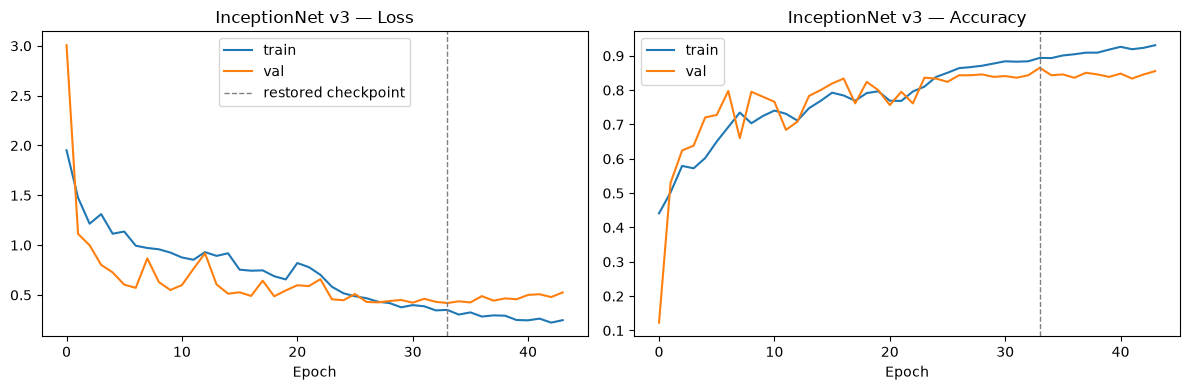

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.854


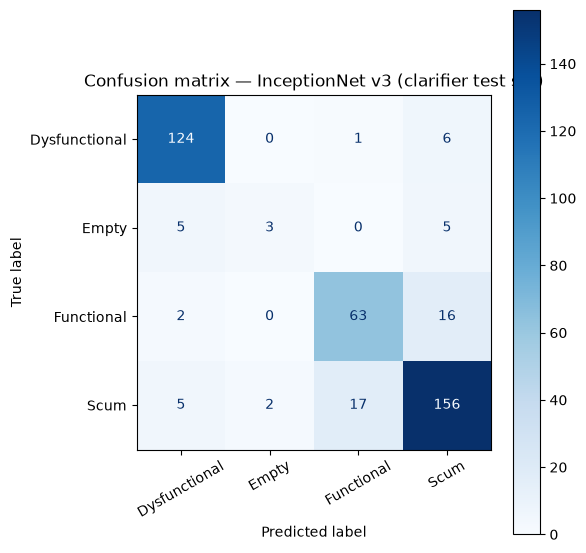

               precision    recall  f1-score   support

Dysfunctional      0.912     0.947     0.929       131
        Empty      0.600     0.231     0.333        13
   Functional      0.778     0.778     0.778        81
         Scum      0.852     0.867     0.860       180

     accuracy                          0.854       405
    macro avg      0.786     0.705     0.725       405
 weighted avg      0.849     0.854     0.849       405



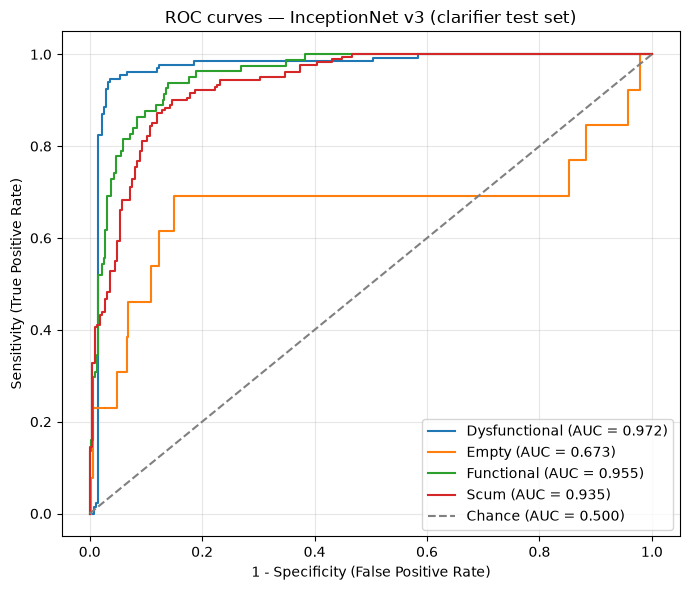

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.972
  Empty          : 0.673
  Functional     : 0.955
  Scum           : 0.935

Mean AUC (over 4/4 classes with test examples): 0.884


(np.float64(0.854320987654321),
 {'Dysfunctional': 0.9723073494177299,
  'Empty': 0.6730769230769232,
  'Functional': 0.9552278616064624,
  'Scum': 0.9354320987654321})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/clarifier_aug/results_clarifier_inception_v3_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
